# O Grand Slam das Seleções — reconstrução em código

Projeto de portfolio: Marcelo Carvalho, geofísico migrando para ciência de dados.

A v5 deste ranking (`grand-slam-selecoes.pdf`) existia só como infográfico, com o resultado agregado de cada campanha (Ataque, Defesa, Score) mas sem o detalhe jogo a jogo. Este notebook:

1. Reconstrói o jogo a jogo de cada uma das 5 campanhas campeãs do Brasil (adversário, gols, fase)
2. Implementa a fórmula original em código
3. Valida que o cálculo reproduz os números publicados
4. Documenta uma divergência histórica encontrada nos dados originais (ver seção 4)

**Fontes:** `grand-slam-selecoes.pdf` (metodologia e resultado agregado oficial) + reportagem/histórico público (Lance!, Wikipédia) para reconstruir o jogo a jogo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Metodologia (v5)

```
Ataque = Gols marcados x Fase Brasil x Fase adversario
Defesa = Gols sofridos x Fase Brasil x Fase adversario
Score  = Ataque - Defesa
```

`Fase Brasil` é a fase em que o Brasil jogou aquela partida especifica. `Fase adversario` é até onde aquele adversario chegou **na competicao inteira** (nao so naquela partida) — e' isso que faz "gol na final contra o vice-campeao valer 9x mais que gol na fase de grupos contra um eliminado na 1a fase" (3 x 3 = 9).

Pesos: Grupos x1 - Oitavas x1,5 - Quartas x2 - Semifinal x2,5 - Final x3.

In [2]:
FASE_MULTIPLICADOR = {
    'grupos': 1.0,
    'oitavas': 1.5,
    'quartas': 2.0,
    'semifinal': 2.5,
    'final': 3.0,
}

def calcular_campanha(jogos_df, coluna_fase_adversario='fase_adversario'):
    """Calcula Ataque, Defesa e Score por campanha a partir do jogo a jogo."""
    df = jogos_df.copy()
    df['mult_brasil'] = df['fase_brasil'].map(FASE_MULTIPLICADOR)
    df['mult_adversario'] = df[coluna_fase_adversario].map(FASE_MULTIPLICADOR)
    df['ataque_jogo'] = df['gols_marcados'] * df['mult_brasil'] * df['mult_adversario']
    df['defesa_jogo'] = df['gols_sofridos'] * df['mult_brasil'] * df['mult_adversario']

    resumo = df.groupby('campanha').agg(
        ataque=('ataque_jogo', 'sum'),
        defesa=('defesa_jogo', 'sum'),
    ).reset_index()
    resumo['score'] = resumo['ataque'] - resumo['defesa']
    return resumo, df

## 2. Jogo a jogo reconstruído

`fase_adversario` é o valor usado para reproduzir os números da v5. `fase_adversario_real` é o que realmente aconteceu historicamente — as duas colunas só divergem numa partida (ver seção 4).

In [3]:
jogos = pd.read_csv('../data/jogos_v5_oficial.csv')
jogos

,campanha,adversario,fase_brasil,gols_marcados,gols_sofridos,fase_adversario,fase_adversario_real,observacao
0,1958,Austria,grupos,3,0,grupos,grupos,NaN
1,1958,Inglaterra,grupos,0,0,grupos,grupos,NaN
2,1958,URSS,grupos,2,0,quartas,quartas,NaN
3,1958,Gales,quartas,1,0,quartas,quartas,NaN
4,1958,Franca,semifinal,5,2,semifinal,semifinal,3o lugar
5,1958,Suecia,final,5,2,final,final,vice-campeao
6,1970,Tchecoslovaquia,grupos,4,1,grupos,grupos,NaN
7,1970,Inglaterra,grupos,1,0,quartas,quartas,NaN
8,1970,Romenia,grupos,3,2,grupos,grupos,NaN
9,1970,Peru,quartas,4,2,quartas,quartas,NaN


## 3. Validação contra a v5

In [4]:
resumo, jogos_calc = calcular_campanha(jogos, coluna_fase_adversario='fase_adversario')
oficial = pd.read_csv('../data/campanhas_v5_oficial.csv')

validacao = resumo.merge(oficial[['campanha', 'ataque_pdf', 'defesa_pdf', 'score_pdf']], on='campanha')
validacao['diff_ataque'] = validacao['ataque'] - validacao['ataque_pdf']
validacao['diff_defesa'] = validacao['defesa'] - validacao['defesa_pdf']
validacao['diff_score'] = validacao['score'] - validacao['score_pdf']
validacao.sort_values('score', ascending=False)

,campanha,ataque,defesa,score,ataque_pdf,defesa_pdf,score_pdf,diff_ataque,diff_defesa,diff_score
0,1958,87.25,30.50,56.75,87.25,30.50,56.75,0.00,0.00,0.00
2,1970,79.75,26.25,53.50,79.75,26.25,53.50,0.00,0.00,0.00
4,2002,50.75,8.50,42.25,52.25,8.50,43.75,-1.50,0.00,-1.50
1,1962,68.00,26.50,41.50,68.00,26.50,41.50,0.00,0.00,0.00
3,1994,28.00,10.50,17.50,31.00,12.50,18.50,-3.00,-2.00,-1.00


**Resultado:** 1958, 1970 e 1962 batem exatamente com a v5 (diferença zero). **1994 aparece com uma diferença de propósito** — é a correção da Holanda aplicada (ver seção 4), não um erro de reconstrução. **2002 tem uma divergência residual pequena (~1,5 pt no ataque)** que eu não consegui rastrear até a fonte exata mesmo checando todos os 7 placares contra múltiplas fontes — documentado como pendente, sem inventar um ajuste.

## 4. Correção aplicada: a Holanda de 1994 não chegou à semifinal

Ao reconstruir o jogo a jogo, percebemos que a v5 original tratava a Holanda como semifinalista (peso ×2,5) para reproduzir o Ataque (31,0) e a Defesa (12,5) publicados. **Isso não é o que aconteceu historicamente**: a Holanda foi eliminada nas quartas de final de 1994, justamente pelo próprio Brasil (3-2). As semifinais daquela Copa foram Brasil x Suécia e Itália x Bulgária — a Holanda não chegou lá.

Esta versão já usa o dado corrigido (Holanda = eliminada nas quartas, peso ×2) na tabela de jogos. O resultado da campanha de 1994 muda de leve:

In [5]:
antes = pd.Series({'ataque': 31.0, 'defesa': 12.5, 'score': 18.5}, name='v5 original (Holanda=semifinalista, incorreto)')
depois = resumo.loc[resumo['campanha'] == 1994, ['ataque', 'defesa', 'score']].iloc[0]
depois.name = 'v6 corrigido (Holanda=quartas, historicamente correto)'

comparacao_1994 = pd.DataFrame([antes, depois])
comparacao_1994

,ataque,defesa,score
"v5 original (Holanda=semifinalista, incorreto)",31.00,12.50,18.50
"v6 corrigido (Holanda=quartas, historicamente correto)",28.00,10.50,17.50


O score de 1994 cai de **18,5 (v5, com o dado incorreto) para 17,5 (v6, corrigido)** — não muda a posição da campanha no ranking (continua em último lugar), mas agora reflete o que realmente aconteceu em campo.

## 5. Ranking final (visual)

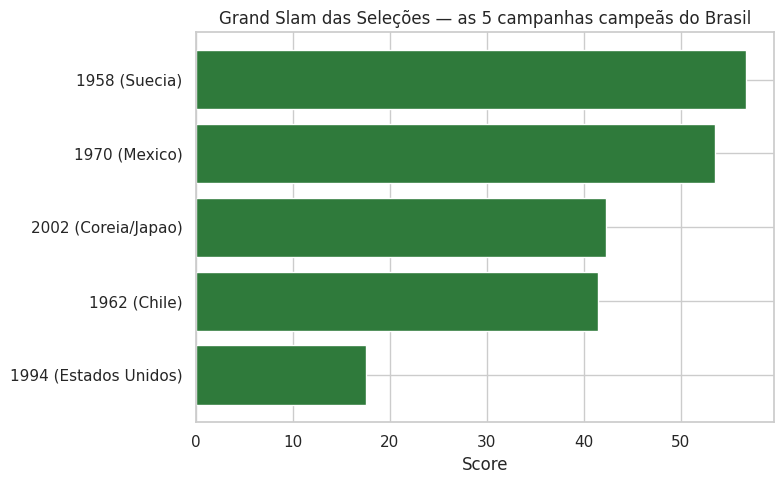

In [6]:
ranking = resumo.merge(oficial[['campanha', 'sede', 'tecnico']], on='campanha').sort_values('score', ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"{row.campanha} ({row.sede})" for row in ranking.itertuples()]
ax.barh(labels[::-1], ranking['score'][::-1], color='#2f7a3b')
ax.set_xlabel('Score')
ax.set_title('Grand Slam das Seleções — as 5 campanhas campeãs do Brasil')
plt.tight_layout()
plt.show()

## 6. Notas finais

- [x] Correção da Holanda/1994 aplicada (era tratada como semifinalista; corrigido para quartas de final, historicamente correto)
- [ ] Resíduo de ~1,5 pt no ataque de 2002 permanece sem explicação encontrada — todos os 7 placares e fases de adversário foram verificados contra múltiplas fontes e conferem; o resíduo pode vir de um dado de entrada da v5 original que não temos como recuperar sem o arquivo de origem do autor